# Grounding-Line Synthetic DAS Workflow

This notebook loads the grounding-line SPECFEM2D receiver output, projects it onto a straight fiber direction, and builds a gauge-length DAS strain-rate product that you can use for first-pass reflection analysis.


In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from io_utils import load_gather
from synthetic import clip_time_window, project_velocity, synthesize_das, fk_filter

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'seismic'


In [14]:
# Main editable parameters
output_dir = Path('../OUTPUT_FILES')
station_prefix = 'S'   # 'S' is near-surface, 'B' is the shallow buried line
fiber_angle_deg = 0.0 # 0 = horizontal fiber along x
gauge_length_m = 50.0
channel_spacing_m = 25.0
plot_tmin = 0.0
plot_tmax = 10.0


In [15]:
gather_x = load_gather(output_dir, component='BXX', station_prefix=station_prefix)
gather_z = load_gather(output_dir, component='BXZ', station_prefix=station_prefix)

print(f'Loaded {gather_x.data.shape[0]} traces with {gather_x.data.shape[1]} samples each')
print(f'x range: {gather_x.x.min():.1f} m to {gather_x.x.max():.1f} m')
print(f't range: {gather_x.time.min():.3f} s to {gather_x.time.max():.3f} s')


Loaded 67 traces with 18000 samples each
x range: -3500.0 m to -200.0 m
t range: -0.120 s to 10.679 s


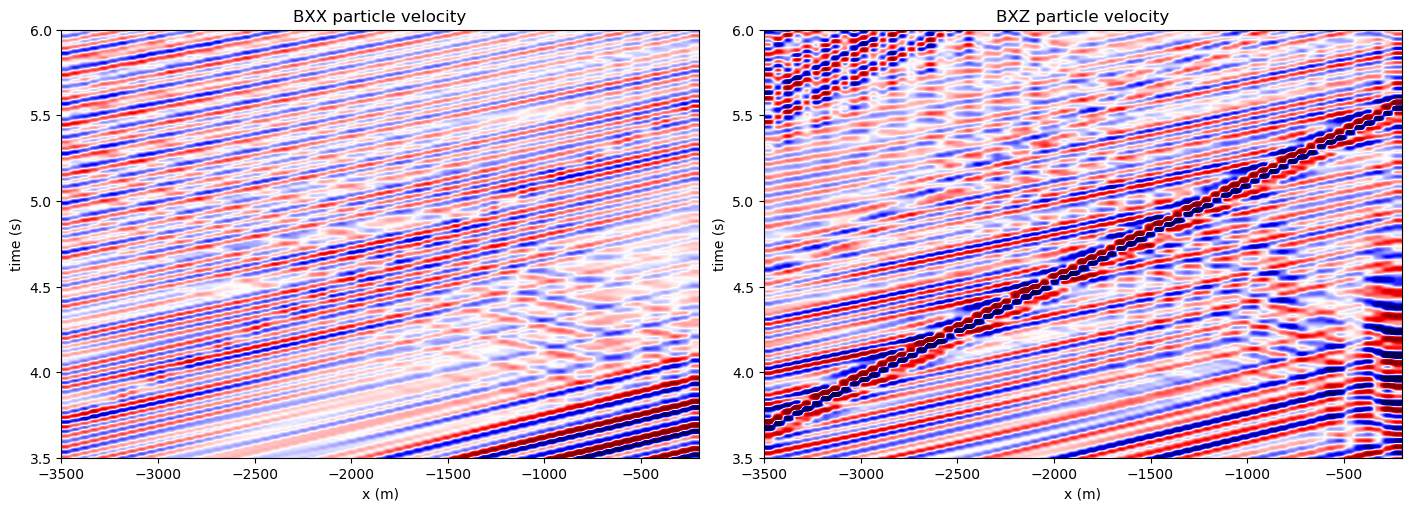

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

clip = np.percentile(np.abs(gather_x.data), 99)
axes[0].imshow(
    gather_x.data.T,
    origin='lower',
    aspect='auto',
    extent=[gather_x.x.min(), gather_x.x.max(), gather_x.time.min(), gather_x.time.max()],
    vmin=-clip,
    vmax=clip,
)
axes[0].set_title('BXX particle velocity')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('time (s)')

clip = np.percentile(np.abs(gather_z.data), 99)
axes[1].imshow(
    gather_z.data.T,
    origin='lower',
    aspect='auto',
    extent=[gather_z.x.min(), gather_z.x.max(), gather_z.time.min(), gather_z.time.max()],
    vmin=-clip,
    vmax=clip,
)
axes[1].set_title('BXZ particle velocity')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('time (s)')

for ax in axes:
    ax.set_ylim([3.5,6.0])
plt.show()


In [17]:
fiber_velocity = project_velocity(gather_x, gather_z=gather_z, fiber_angle_deg=fiber_angle_deg)
das = synthesize_das(
    fiber_velocity,
    gauge_length_m=gauge_length_m,
    channel_spacing_m=channel_spacing_m,
)
das = clip_time_window(das, tmin=plot_tmin, tmax=plot_tmax)

print(f'DAS channels: {das.strain_rate.shape[0]}')
print(f'Gauge length: {das.gauge_length_m:.1f} m')
print(f'Channel spacing: {das.channel_spacing_m:.1f} m')


DAS channels: 131
Gauge length: 50.0 m
Channel spacing: 25.0 m


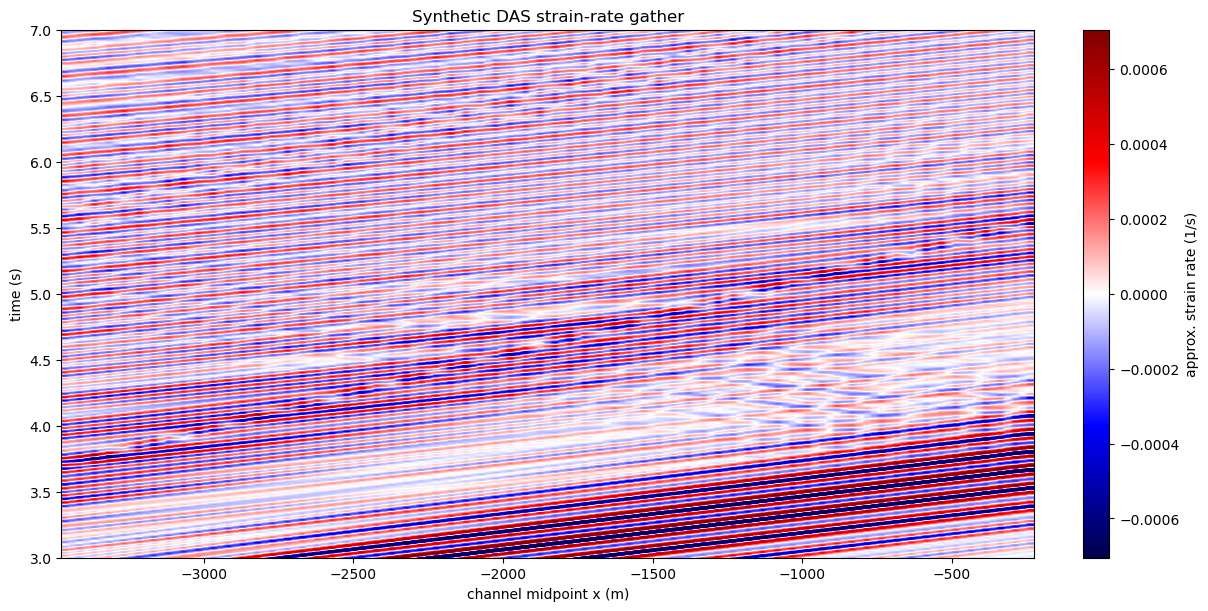

In [18]:
# enable interactive mode so I can zoom in on the plot
# %matplotlib notebook

clip = np.percentile(np.abs(das.strain_rate), 99)

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
im = ax.imshow(
    das.strain_rate.T,
    origin='lower',
    aspect='auto',
    extent=[das.x.min(), das.x.max(), das.time.min(), das.time.max()],
    vmin=-clip,
    vmax=clip,
)
ax.set_title('Synthetic DAS strain-rate gather')
ax.set_xlabel('channel midpoint x (m)')
ax.set_ylabel('time (s)')
fig.colorbar(im, ax=ax, label='approx. strain rate (1/s)')

plt.ylim([3,7])

plt.show()


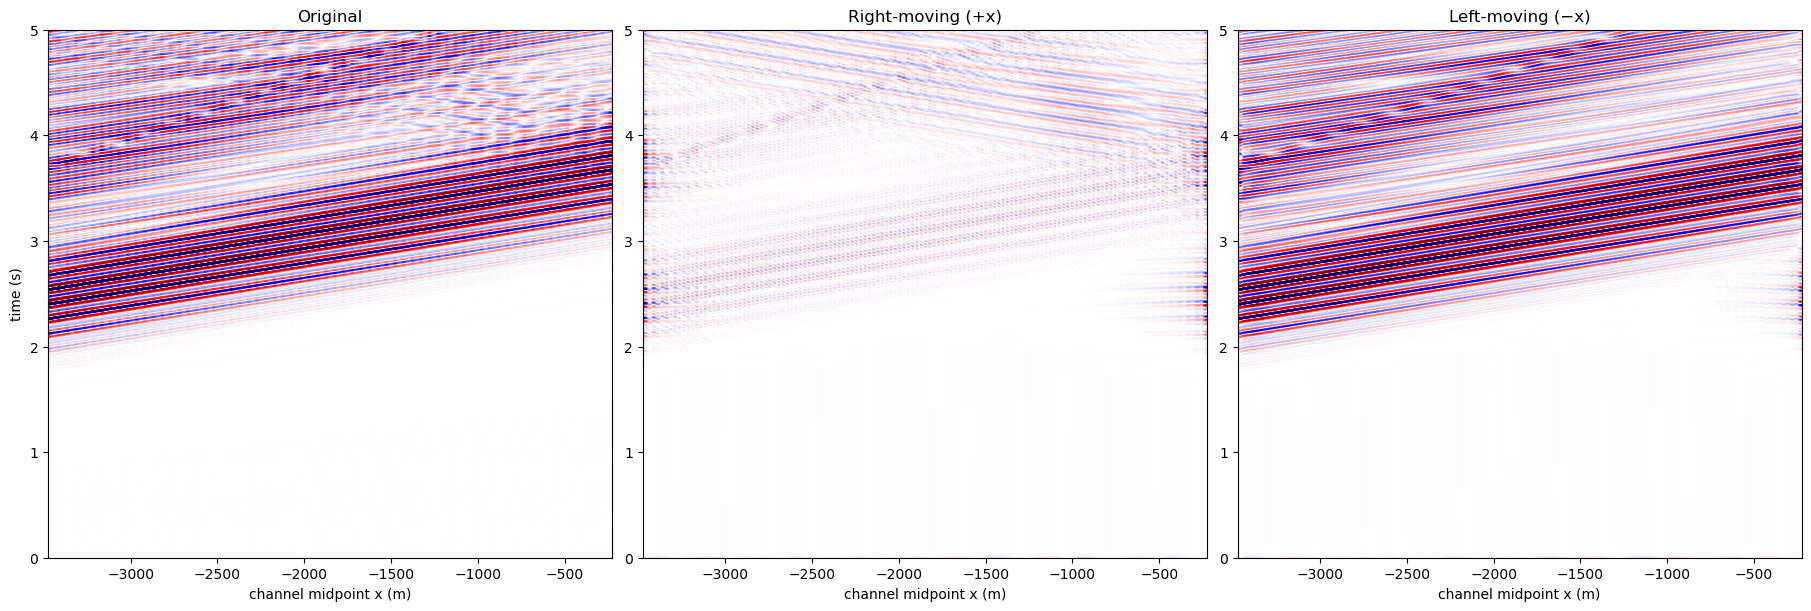

In [23]:
# FK filter: separate left-moving and right-moving waves
das_right = fk_filter(das, direction='right', taper_width=5)
das_left  = fk_filter(das, direction='left',  taper_width=5)

clip_r = np.percentile(np.abs(das_right.strain_rate), 99)
clip_l = np.percentile(np.abs(das_left.strain_rate), 99)
clip_both = max(clip_r, clip_l)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Original
axes[0].imshow(
    das.strain_rate.T, origin='lower', aspect='auto',
    extent=[das.x.min(), das.x.max(), das.time.min(), das.time.max()],
    vmin=-clip, vmax=clip,
)
axes[0].set_title('Original')
axes[0].set_xlabel('channel midpoint x (m)')
axes[0].set_ylabel('time (s)')

# Right-moving
axes[1].imshow(
    das_right.strain_rate.T, origin='lower', aspect='auto',
    extent=[das.x.min(), das.x.max(), das.time.min(), das.time.max()],
    vmin=-clip_both, vmax=clip_both,
)
axes[1].set_title('Right-moving (+x)')
axes[1].set_xlabel('channel midpoint x (m)')

# Left-moving
axes[2].imshow(
    das_left.strain_rate.T, origin='lower', aspect='auto',
    extent=[das.x.min(), das.x.max(), das.time.min(), das.time.max()],
    vmin=-clip_both, vmax=clip_both,
)
axes[2].set_title('Left-moving (−x)')
axes[2].set_xlabel('channel midpoint x (m)')

for ax in axes:
    ax.set_ylim([0, 5])

plt.show()


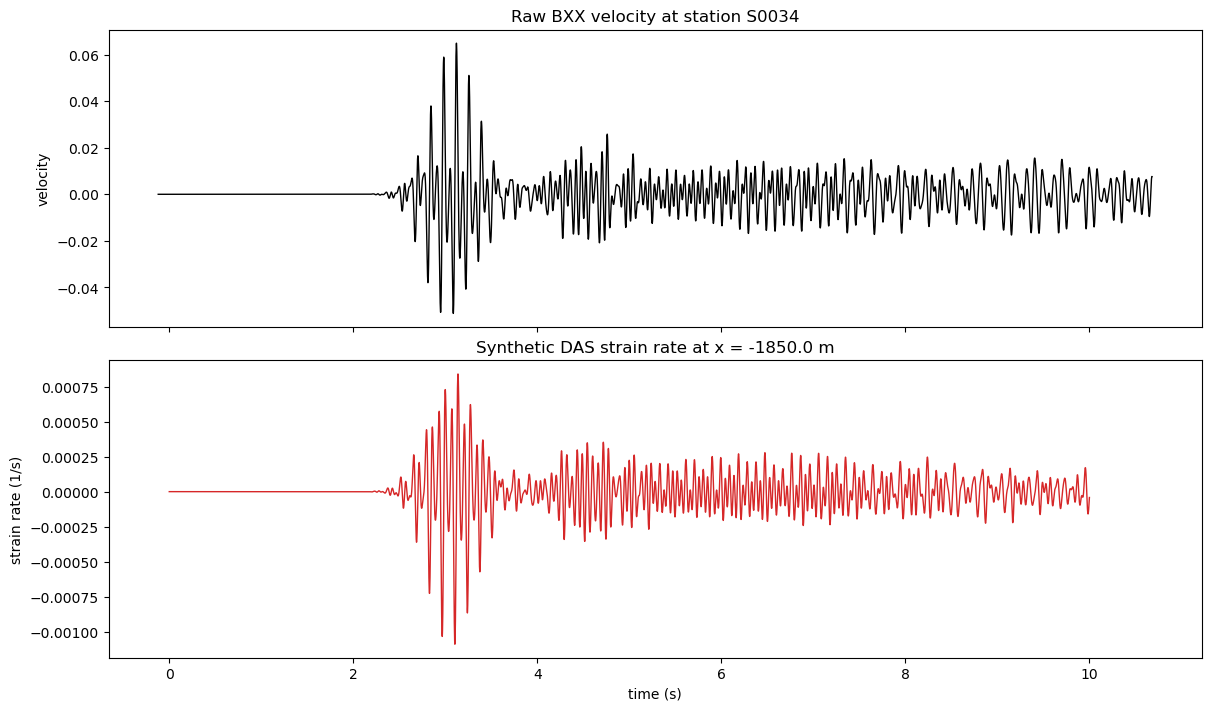

In [20]:
# Compare one raw trace with one DAS channel near the middle of the aperture
mid_trace = gather_x.data.shape[0] // 2
mid_channel = das.strain_rate.shape[0] // 2

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(gather_x.time, gather_x.data[mid_trace], color='black', lw=1.0)
axes[0].set_title(f'Raw BXX velocity at station {gather_x.stations[mid_trace]}')
axes[0].set_ylabel('velocity')

axes[1].plot(das.time, das.strain_rate[mid_channel], color='tab:red', lw=1.0)
axes[1].set_title(f'Synthetic DAS strain rate at x = {das.x[mid_channel]:.1f} m')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('strain rate (1/s)')
plt.show()


In [21]:
# Optional: save the DAS product for later use
output_npz = Path('products/surface_das_notebook.npz')
output_npz.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    output_npz,
    time=das.time,
    x=das.x,
    strain_rate=das.strain_rate,
    gauge_length_m=das.gauge_length_m,
    channel_spacing_m=das.channel_spacing_m,
    station_prefix=station_prefix,
)
print(f'Saved {output_npz}')


Saved products/surface_das_notebook.npz


## Notes

- For a horizontal fiber, the main input is `BXX`, because DAS is sensitive to axial deformation along the cable.
- To test a tilted fiber, change `fiber_angle_deg` and rerun the notebook.
- To mimic denser DAS sampling, reduce `channel_spacing_m` as long as your receiver aperture is dense enough to support interpolation.
- To compare buried and surface arrays, switch `station_prefix` between `'S'` and `'B'`.
